In [85]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [86]:
import pickle
from pathlib import Path

import numpy as np
import numpy.random as npr
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from scipy.optimize import linear_sum_assignment
import statsmodels.formula.api as smf

from imports import *
from config import dir_config
from src.utils import pmf_utils
from src.shared_glm_hmm.grouping import session_metadata

In [87]:
processed_dir = Path(dir_config.data.processed)
shared_dir = processed_dir / "shared_glm_hmm"

metadata = pd.read_csv(processed_dir / "processed_metadata_all_data_accu_60.csv")
sess_md = session_metadata(metadata).set_index("session_id")

# trial-level behaviour (for per-trial color when a config lacks the color regressor)
behavior_df = pd.read_csv(processed_dir / "processed_all_data_accu_60_all.csv")
behavior_df["outcome"] = behavior_df["outcome"].fillna(-1)


## Select model for the within-subject analysis

The panels above compare all runs. Pick **one** model here; sections 1–6 below run on it.

In [88]:
SELECTED = "XY__tgt"   # the model for the downstream within-subject analysis

CONFIG = SELECTED
bundle = pickle.load(open(shared_dir / CONFIG / "all_subjects_final.pkl", "rb"))
pooled = bundle["model"]["pooled"]
feats  = bundle["config"]["model_features"]
K      = bundle["best_k"]
data   = bundle["data"]


STATE_COLORS = ["#ff7f00", "#4daf4a", "#377eb8", "#e41a1c", "#984ea3", "#a65628", "#999999"]
GROUP_LABELS = {
    ("HC", "none"): "HC",
    ("tremor", "off"): "Tremor OFF",
    ("tremor", "on"): "Tremor ON",
    ("bradykinetic", "off"): "Brady OFF",
    ("bradykinetic", "on"): "Brady ON",
    ("intermediate", "off"): "Interm OFF",
    ("intermediate", "on"): "Interm ON",
}


In [89]:
def get_state_colors(Kn):
    return [STATE_COLORS[k % len(STATE_COLORS)] for k in range(Kn)]


def state_label(k):
    return f"State {k + 1}"


def _align(w, ref):
    cost = np.array([[np.sum((w[i] - ref[j]) ** 2) for j in range(len(ref))] for i in range(len(w))])
    _, col = linear_sum_assignment(cost)
    inv = np.empty_like(col)
    inv[col] = np.arange(len(col))
    return inv


def get_session_color(sid, n_back):
    """Per-trial color for one session, trimmed to match the bundle (process_sessions logic)."""
    td = behavior_df[behavior_df["session_id"] == sid].reset_index(drop=True)
    valid_idx = np.where(td["outcome"].values != -1)[0]
    first_trial = valid_idx[n_back - 1] + 1
    return td["color"].values[first_trial:]


def build_group_data(bundle, sess_md):
    """{group_tuple: {session_weights, session_occupancy, session_predicted_dfs}} on shared basis."""
    ref_w = -bundle["model"]["pooled"].observations.params[:, 0, :]  # (K, M) this run's shared basis
    n_back = bundle["config"].get("n_trials_back", 1)
    groups = {}
    for sid, m in bundle["model"]["models"].items():
        if sid not in sess_md.index:
            continue
        g = (sess_md.loc[sid, "subtype"], sess_md.loc[sid, "medication"])
        df = bundle["data"][sid]
        X = df[feats].values.astype(float)
        y = df["choices"].values.astype(int).reshape(-1, 1)
        msk = df["mask"].values.astype(bool).reshape(-1, 1)
        post = m.expected_states(data=y, input=X, mask=msk)[0]  # (T, K)
        w = -m.observations.params[:, 0, :]
        perm = _align(w, ref_w)
        valid = msk[:, 0]
        # expected choice prob (permutation-invariant)
        wsum = np.einsum("tm,km->tk", X, w)
        sig = 1 / (1 + np.exp(-wsum))
        ecp = (sig * post).sum(1)
        color_raw = df["color"].values if "color" in df.columns else get_session_color(sid, n_back)
        pdf = pd.DataFrame(
            {
                "stimulus": df["stimulus"].values[valid],
                "choices": y[valid, 0],
                "color": (color_raw[valid] > 0).astype(int),  # equal=0, unequal=1
                "expected_choice_prob": np.clip(ecp[valid], 1e-6, 1 - 1e-6),
            }
        )
        gd = groups.setdefault(g, {"session_weights": {}, "session_occupancy": {}, "session_predicted_dfs": {}})
        gd["session_weights"][sid] = w[perm]
        gd["session_occupancy"][sid] = post[:, perm][valid].mean(0)
        gd["session_predicted_dfs"][sid] = pdf
    return groups


def compute_group_psychometrics(predicted_dfs):
    conditions = [(0, "Equal", "gray"), (1, "Unequal", "black")]
    result = {}
    for cval, label, color in conditions:
        actual, model = [], []
        x_bins = x_hat = None
        for pdf in predicted_dfs.values():
            sub = pdf[pdf["color"] == cval]
            if len(sub) < 5:
                continue
            stim = sub["stimulus"].to_numpy() * 100
            ch = sub["choices"].values.astype(int)
            ep = sub["expected_choice_prob"].values
            try:
                xd, yd, _, xh, _ = pmf_utils.get_psychometric_data({"signed_coherence": stim, "choice": ch})
                actual.append(yd)
                if x_bins is None:
                    x_bins, x_hat = xd, xh
                # _, ym, _, _, _ = pmf_utils.get_psychometric_data({"signed_coherence": stim, "choice": npr.binomial(1, ep)})
                ym = np.array([ep[stim == c].mean() for c in x_bins])
                model.append(ym)
            except Exception:
                continue
        if not actual:
            continue
        ya, ym = np.array(actual), np.array(model)
        S = len(actual)

        def safe_fit(y):
            try:
                return pmf_utils.fit_psychometric_function(x_bins, y, trial_counts=None, model_type="logit_4").predict(x_hat)
            except Exception:
                return None

        result[cval] = dict(
            label=label,
            color=color,
            x_bins=x_bins,
            x_hat=x_hat,
            actual=actual,
            model=model,
            mean_actual=ya.mean(0),
            sem_actual=ya.std(0) / np.sqrt(S),
            mean_model=ym.mean(0),
            sem_model=ym.std(0) / np.sqrt(S),
            fit_actual=safe_fit(ya.mean(0)),
            fit_model=safe_fit(ym.mean(0)),
        )
    return result

def plot_color_psych(ax, gp, mode, title=""):
    for cval in sorted(gp):
        c = gp[cval]
        col = c["color"]
        for ys in c[mode]:
            ax.plot(c["x_bins"], ys, "o-", color=col, alpha=0.08, lw=0.8, ms=3)
        ax.errorbar(c["x_bins"], c[f"mean_{mode}"], yerr=c[f"sem_{mode}"], color=col, marker="o", ms=9, mec="k", ls="", label=c["label"], elinewidth=2, capsize=7)
        if c[f"fit_{mode}"] is not None:
            ax.plot(c["x_hat"], c[f"fit_{mode}"], color=col, ls="-", lw=2.5)
    ax.axhline(0.5, color="k", ls=":", lw=0.8)
    ax.set(xlabel="Coherence (%)", ylabel="P(right)", xlim=(-105, 105), ylim=(-0.05, 1.05), xticks=[-100, -35, -13, 0, 13, 35, 100], title=title)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)


def plot_group_row(axrow, group, gd):
    label = GROUP_LABELS.get(group, str(group))
    colors = get_state_colors(K)
    ax_beh, ax_mdl, ax_psych, ax_w, ax_occ = axrow
    gp = compute_group_psychometrics(gd["session_predicted_dfs"])
    plot_color_psych(ax_beh, gp, "actual", f"{label} — Behavior")
    plot_color_psych(ax_mdl, gp, "model", f"{label} — GLM-HMM")

    Wg = np.stack(list(gd["session_weights"].values()))
    S = len(Wg)
    Og = np.stack(list(gd["session_occupancy"].values()))
    mean_w, sem_w = Wg.mean(0), Wg.std(0) / np.sqrt(S)
    mean_o, sem_o = Og.mean(0), Og.std(0) / np.sqrt(S)

    si = feats.index("stimulus") if "stimulus" in feats else 0
    bi = feats.index("bias") if "bias" in feats else None

    ci = next((i for i, f in enumerate(feats) if f == "color"), None)
    cXs_i = next((i for i, f in enumerate(feats) if "color" in f and "stim" in f.lower()), None)

    xr = np.linspace(-1, 1, 200)

    for k in range(K):
        for c in [0, 1]:
            logit = mean_w[k, si] * xr
            if bi is not None:
                logit += mean_w[k, bi]
            if ci is not None:
                logit += mean_w[k, ci] * c
            if cXs_i is not None:
                logit += mean_w[k, cXs_i] * xr * c
            ls = "--" if c == 0 else "-"
            ax_psych.plot(xr * 100, 1 / (1 + np.exp(-logit)), color=colors[k], lw=2, ls=ls, label=state_label(k))

    ax_psych.axhline(0.5, color="k", ls=":", lw=0.8)
    ax_psych.set(xlabel="Coherence (%)", ylabel="P(right)", ylim=(0, 1), title=f"{label} — states")
    ax_psych.legend(fontsize=7)

    xf = np.arange(len(feats))
    for k in range(K):
        ax_w.errorbar(xf, mean_w[k], yerr=sem_w[k], color=colors[k], marker="o", lw=1.4, capsize=3, label=state_label(k))
    ax_w.axhline(0, color="k", ls="--", lw=0.8)
    ax_w.set_xticks(xf)
    ax_w.set_xticklabels(feats, rotation=20, ha="right", fontsize=8)
    ax_w.set(ylabel="GLM weight", title="Weights (mean ± SEM)")
    ax_w.legend(fontsize=7)

    xk = np.arange(K)
    ax_occ.bar(xk, mean_o, color=colors, alpha=0.85, yerr=sem_o, capsize=4)
    for k in range(K):
        ax_occ.scatter(np.full(S, k) + np.random.uniform(-0.15, 0.15, S), Og[:, k], color=colors[k], s=10, alpha=0.5, zorder=3)
    ax_occ.set_xticks(xk)
    ax_occ.set_xticklabels([f"S{k+1}" for k in range(K)])
    ax_occ.set(ylabel="Occupancy", ylim=(0, 1), title="State occupancy")

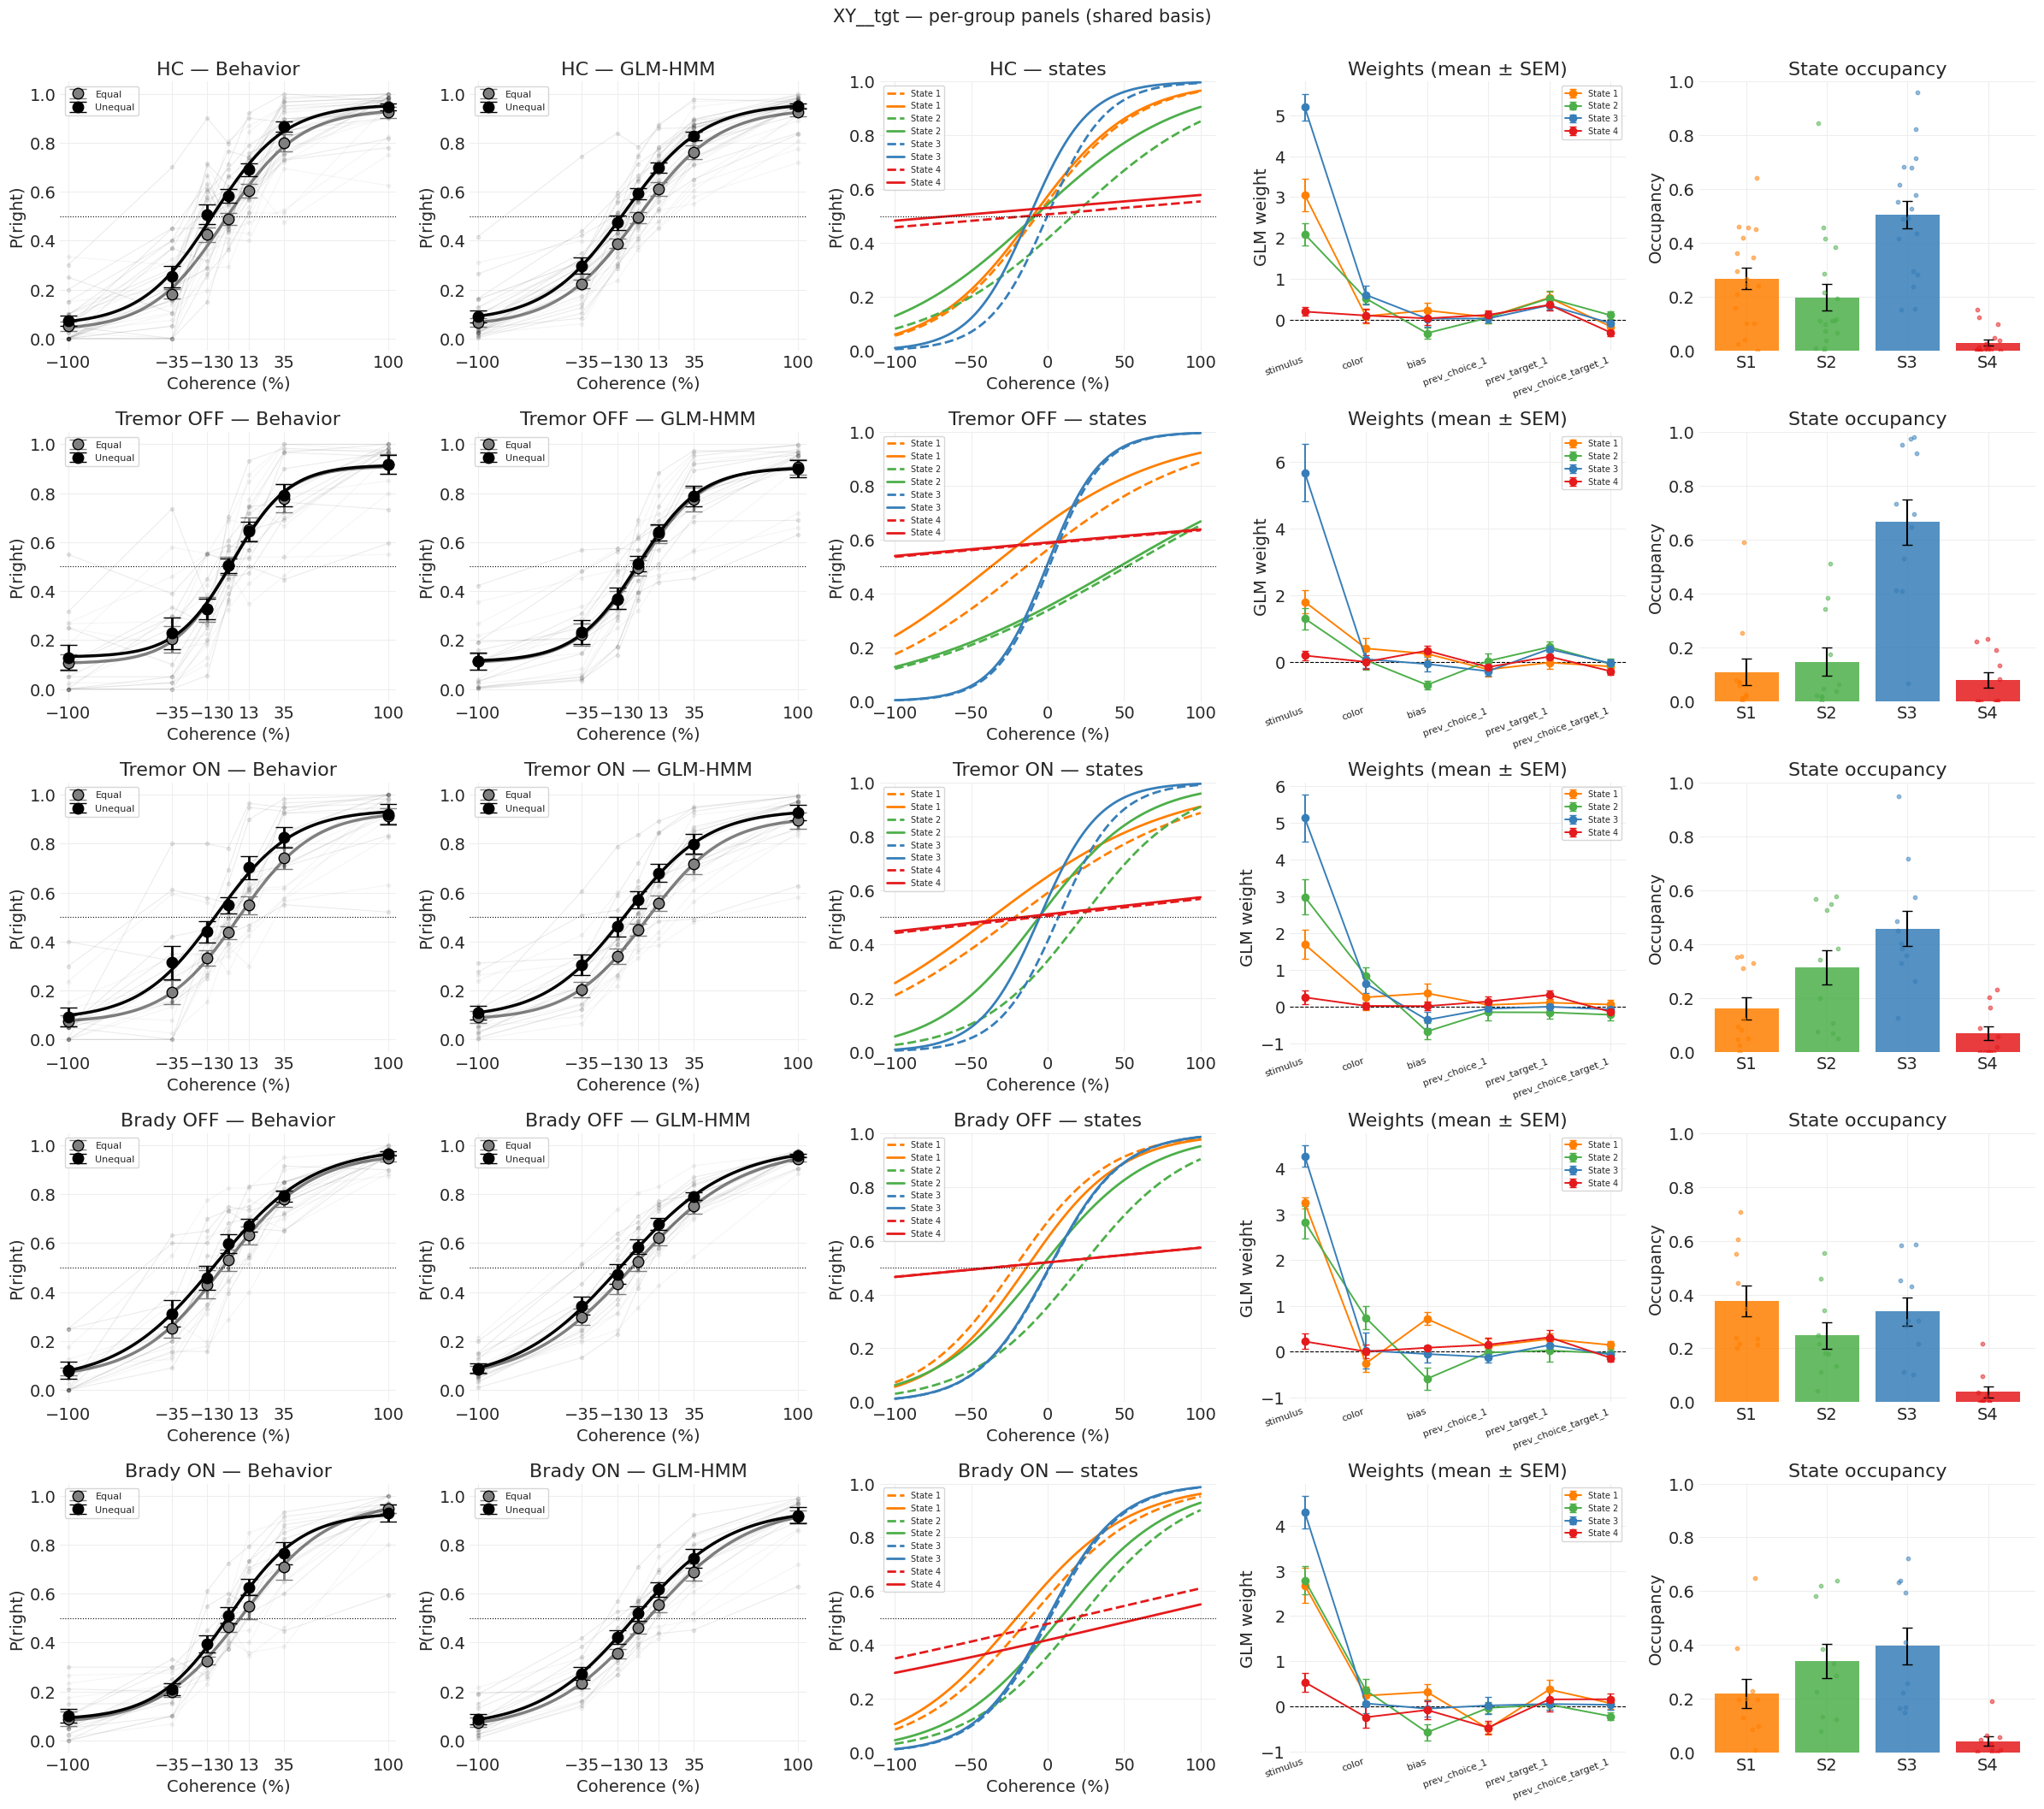

In [90]:

group_data = build_group_data(bundle, sess_md)
GROUP_ORDER = [("HC","none"), ("tremor","off"), ("tremor","on"),
               ("bradykinetic","off"), ("bradykinetic","on")]
GROUP_ORDER = [g for g in GROUP_ORDER if g in group_data]

nG = len(GROUP_ORDER)
fig, axes = plt.subplots(nG, 5, figsize=(24, 4.2*nG), squeeze=False)
for row, g in enumerate(GROUP_ORDER):
    plot_group_row(axes[row], g, group_data[g])
fig.suptitle(f"{SELECTED} \u2014 per-group panels (shared basis)", fontsize=15, y=1.005)
plt.tight_layout();
plt.show()

# 0.1 Individual State Weight plots

In [105]:
def plot_group_state_psych(axrow, group, gd):
    label = GROUP_LABELS.get(group, str(group))
    colors = get_state_colors(K)

    Wg = np.stack(list(gd["session_weights"].values()))
    S = len(Wg)
    Og = np.stack(list(gd["session_occupancy"].values()))
    mean_w, sem_w = Wg.mean(0), Wg.std(0) / np.sqrt(S)
    mean_o, sem_o = Og.mean(0), Og.std(0) / np.sqrt(S)

    si = feats.index("stimulus") if "stimulus" in feats else 0
    bi = feats.index("bias") if "bias" in feats else None

    ci = next((i for i, f in enumerate(feats) if f == "color"), None)
    cXs_i = next((i for i, f in enumerate(feats) if "color" in f and "stim" in f.lower()), None)

    xr = np.linspace(-1, 1, 200)

    for ax, k in zip(axrow, range(K)):
        for c in [0, 1]:
            logit = mean_w[k, si] * xr
            if bi is not None:
                logit += mean_w[k, bi]
            if ci is not None:
                logit += mean_w[k, ci] * c
            if cXs_i is not None:
                logit += mean_w[k, cXs_i] * xr * c
            ls = "--" if c == 0 else "-"
            ax.plot(xr * 100, 1 / (1 + np.exp(-logit)), color=colors[k], lw=2, ls=ls, label=state_label(k))

        ax.axhline(0.5, color="k", ls=":", lw=0.8)
        ax.set(xlabel="Coherence (%)", ylabel="P(right)", ylim=(0, 1), title=f"{label} — states")
        ax.legend(fontsize=7)

def plot_group_state_weights(axrow, group, gd):
    label = GROUP_LABELS.get(group, str(group))
    colors = get_state_colors(K)

    Wg = np.stack(list(gd["session_weights"].values()))
    S = len(Wg)
    Og = np.stack(list(gd["session_occupancy"].values()))
    mean_w, sem_w = Wg.mean(0), Wg.std(0) / np.sqrt(S)
    mean_o, sem_o = Og.mean(0), Og.std(0) / np.sqrt(S)

    xf = np.arange(len(feats))
    for ax_w, k in zip(axrow, range(K)):
        ax_w.plot(Wg[:, k, :].T, color=colors[k], alpha=0.3, lw=0.8)
        ax_w.errorbar(xf, mean_w[k], yerr=sem_w[k], color="k", marker="o", lw=2, capsize=3, label=state_label(k))
        ax_w.axhline(0, color="k", ls="--", lw=0.8)
        ax_w.set_xticks(xf)
        ax_w.set_xticklabels(feats, rotation=20, ha="right", fontsize=8)
        ax_w.set_ylim(-2.5, 8)
        ax_w.set(ylabel="GLM weight", title=f"{label} — {state_label(k)} weights (mean ± SEM)")
        ax_w.legend(fontsize=7)

def plot_group_state_psych_weights(axrow, group, gd, title=None):

    label = GROUP_LABELS.get(group, str(group))
    colors = get_state_colors(K)

    ax_psych   = axrow[0, np.arange(0, 2*K, 2)]
    ax_weights = axrow[0, np.arange(1, 2*K, 2)]
    si = feats.index("stimulus") if "stimulus" in feats else 0
    bi = feats.index("bias") if "bias" in feats else None
    ci = next((i for i, f in enumerate(feats) if f == "color"), None)
    cXs_i = next((i for i, f in enumerate(feats) if "color" in f and "stim" in f.lower()), None)

    Wg = np.stack(list(gd["session_weights"].values()))
    S = len(Wg)
    Og = np.stack(list(gd["session_occupancy"].values()))
    mean_w, sem_w = Wg.mean(0), Wg.std(0) / np.sqrt(S)
    mean_o, sem_o = Og.mean(0), Og.std(0) / np.sqrt(S)

    xf = np.arange(len(feats))
    for ax_w, k in zip(ax_weights, range(K)):
        ax_w.plot(Wg[:, k, :].T, color=colors[k], alpha=0.3, lw=0.8)
        ax_w.errorbar(xf, mean_w[k], yerr=sem_w[k], color="k", marker="o", lw=2, capsize=3, label=state_label(k))
        ax_w.axhline(0, color="k", ls="--", lw=0.8)
        ax_w.set_xticks(xf)
        ax_w.set_xticklabels(feats, rotation=20, ha="right", fontsize=8)
        ax_w.set_ylim(-2.5, 8)
        # ax_w.set(ylabel="GLM weight", title=f"{label} — {state_label(k)} weights (mean ± SEM)")
        ax_w.legend(fontsize=7)


    xr = np.linspace(-1, 1, 200)
    for ax, k in zip(ax_psych, range(K)):
        for c in [0, 1]:
            logit = mean_w[k, si] * xr
            if bi is not None:
                logit += mean_w[k, bi]
            if ci is not None:
                logit += mean_w[k, ci] * c
            if cXs_i is not None:
                logit += mean_w[k, cXs_i] * xr * c
            ls = "--" if c == 0 else "-"
            ax.plot(xr * 100, 1 / (1 + np.exp(-logit)), color=colors[k], lw=2, ls=ls)#label=state_label(k))

        ax.axhline(0.5, color="k", ls=":", lw=0.8)
        ax.set(xlabel="Coherence (%)", ylabel="P(right)", ylim=(0, 1))#, title=f"{label} — states")
        ax.legend(fontsize=7)

    # Add occupancy plot

    xk = np.arange(K)
    ax_occ = axrow[0, -1]
    ax_occ.bar(xk, mean_o, color=colors, alpha=0.85, yerr=sem_o, capsize=4)
    for k in range(K):
        ax_occ.scatter(np.full(S, k) + np.random.uniform(-0.15, 0.15, S), Og[:, k], color=colors[k], s=10, alpha=0.5, zorder=3)
    ax_occ.set_xticks(xk)
    ax_occ.set_xticklabels([f"S{k + 1}" for k in range(K)])
    ax_occ.set(ylabel="Occupancy", ylim=(0, 1), title="State occupancy")

    if title:
        fig.suptitle(title, fontsize=25, y=1.05)

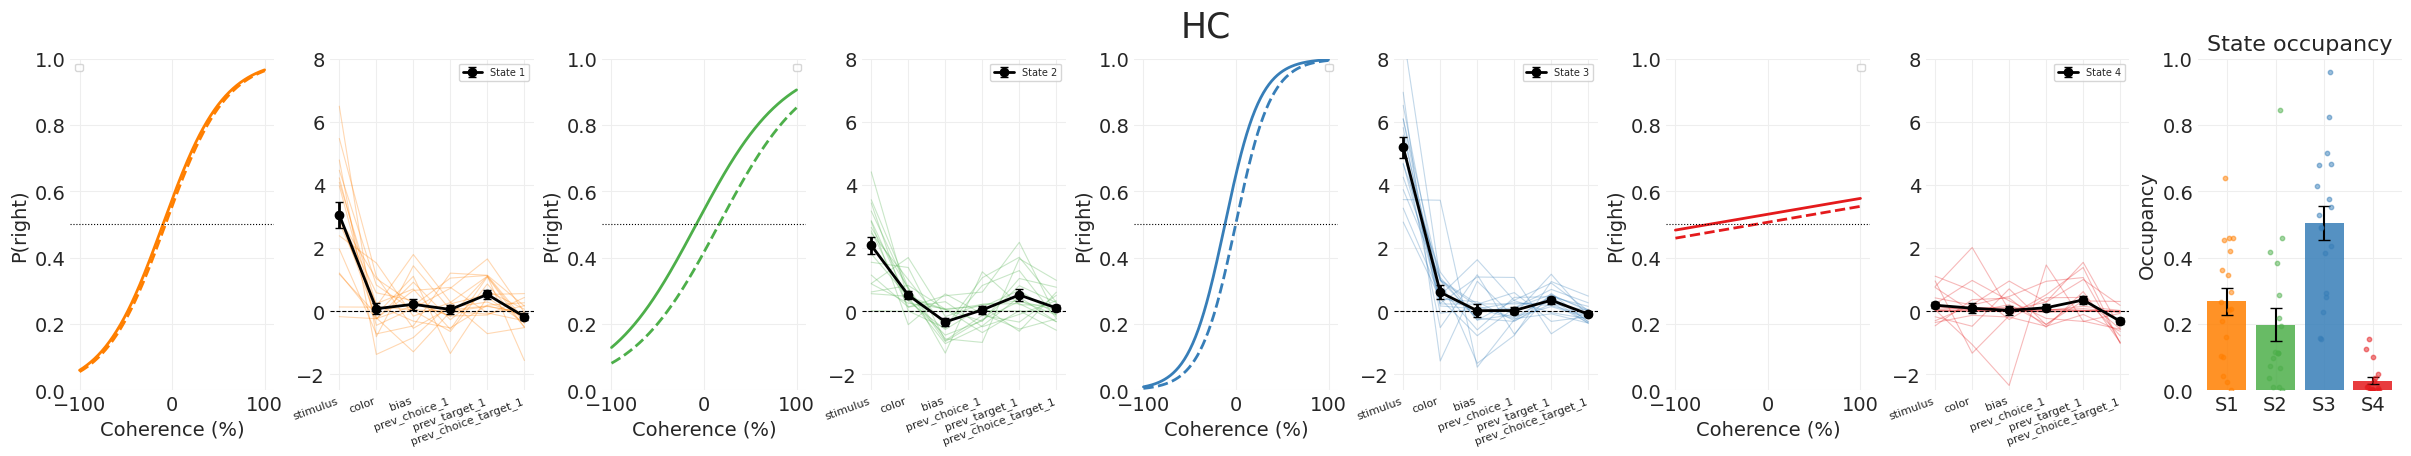

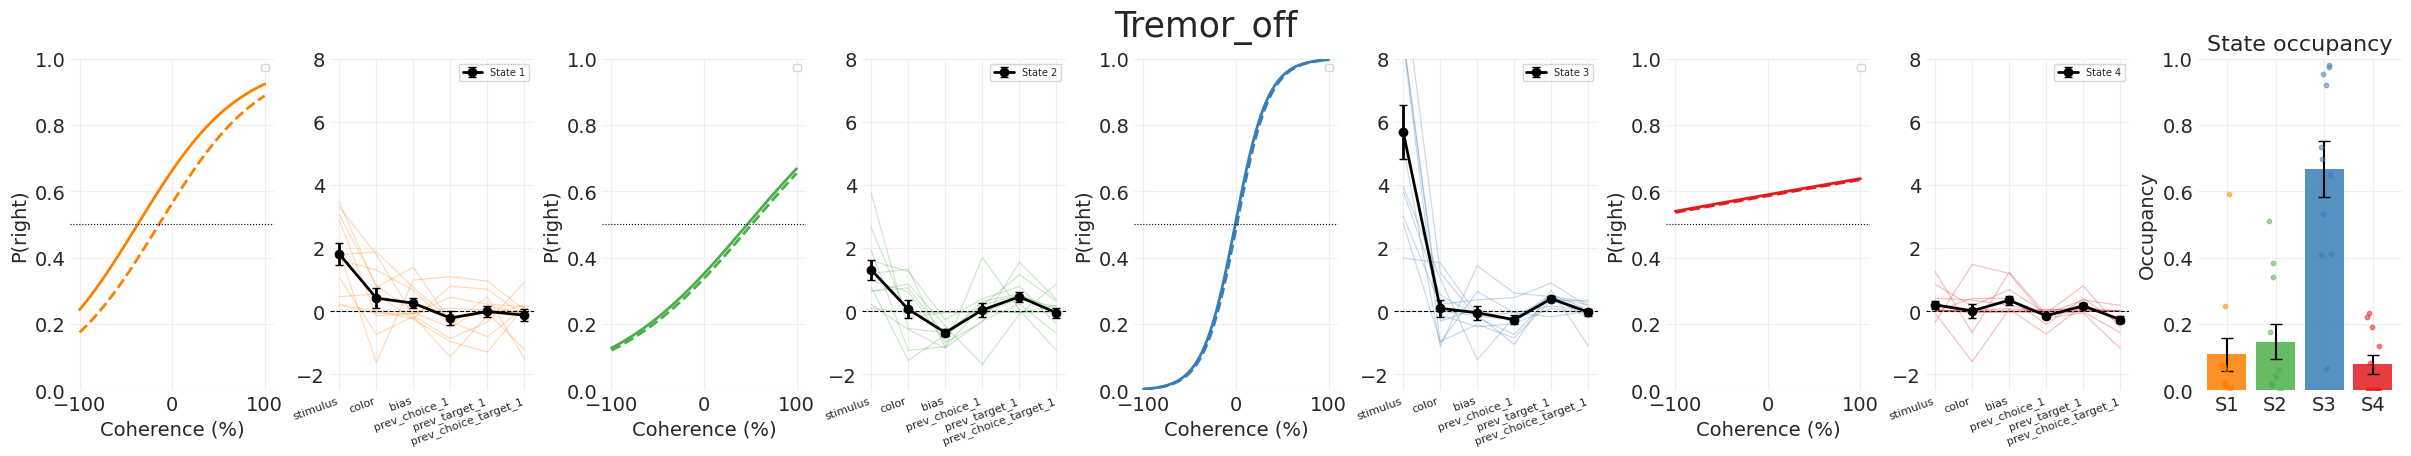

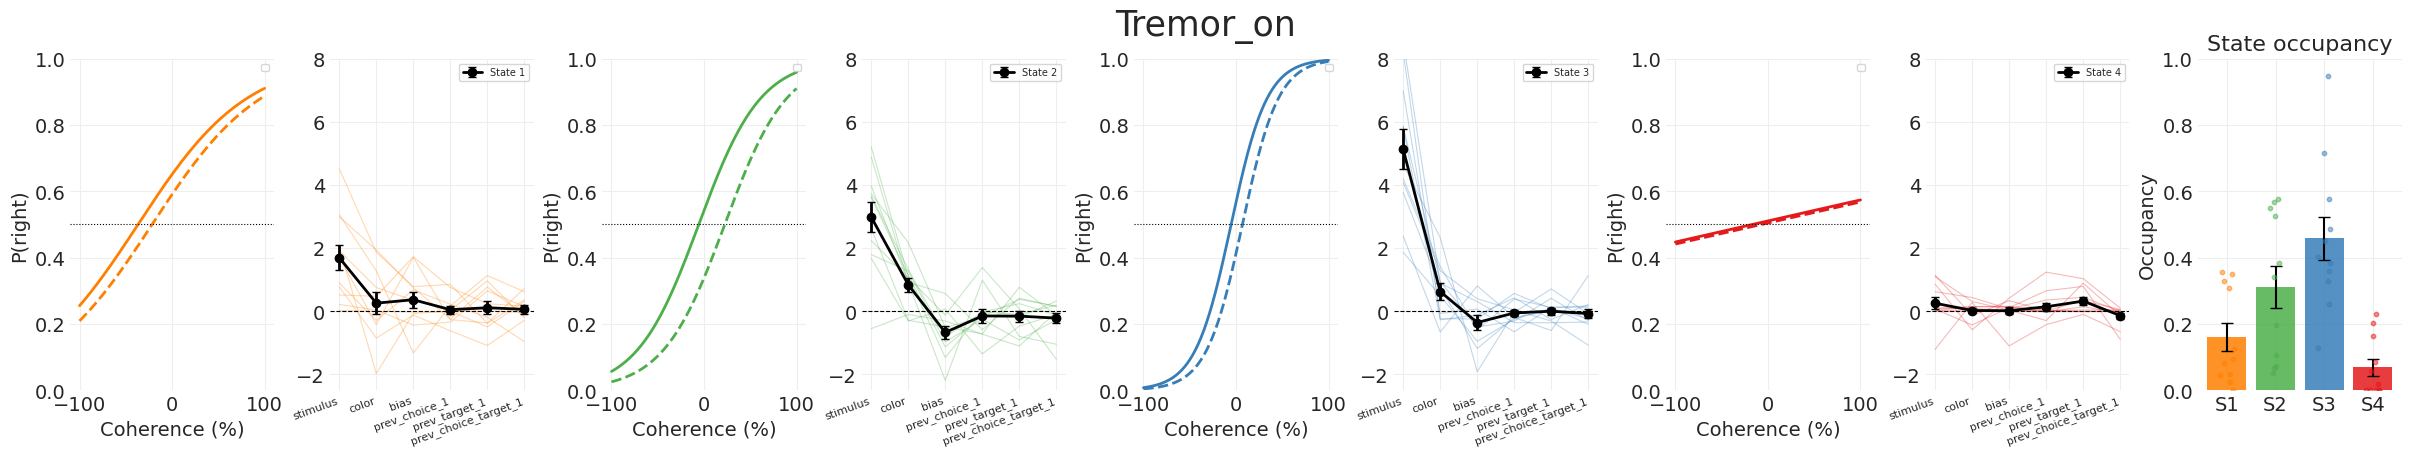

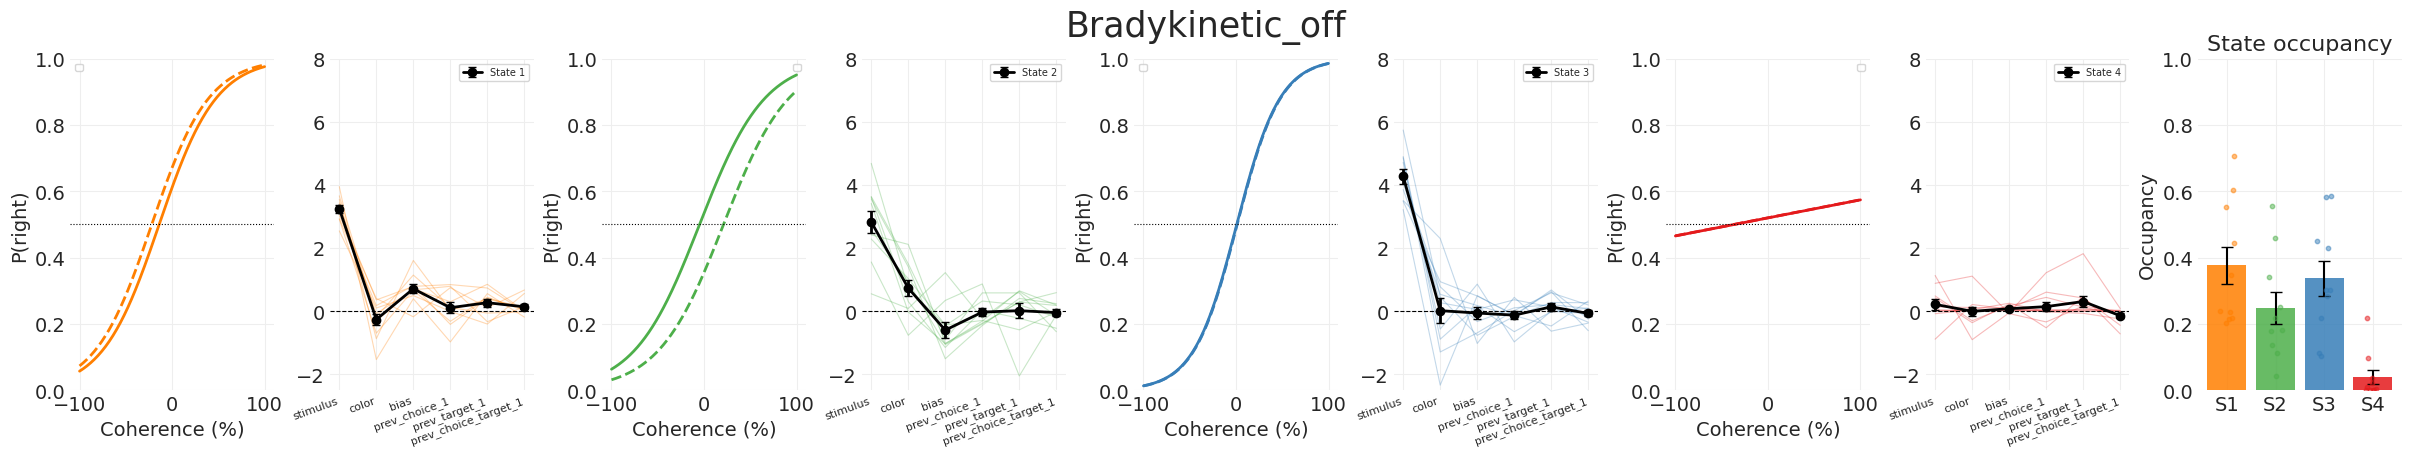

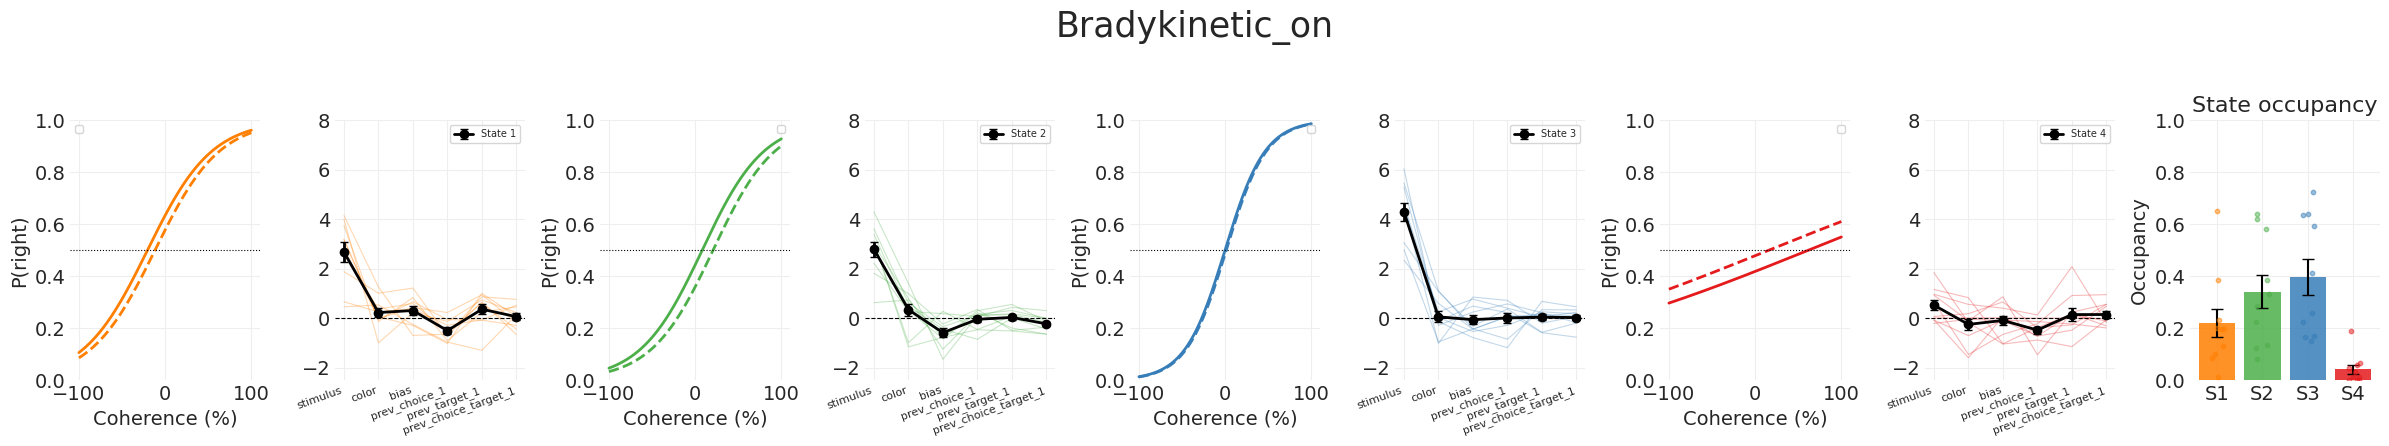

In [106]:
group_data = build_group_data(bundle, sess_md)
GROUP_ORDER = [("HC", "none"), ("tremor", "off"), ("tremor", "on"), ("bradykinetic", "off"), ("bradykinetic", "on")]
GROUP_ORDER = [g for g in GROUP_ORDER if g in group_data]
nG = len(GROUP_ORDER)

for row, g in enumerate(GROUP_ORDER):
    fig, axes = plt.subplots(1, 2*K + 1, figsize=(24, 4.2), squeeze=False)
    title = f"{g[0].capitalize()}_{g[1]}" if g[0] != "HC" else f"{g[0]}"
    plot_group_state_psych_weights(axes, g, group_data[g], title=title)
plt.tight_layout()
plt.show()

In [93]:
group_data = build_group_data(bundle, sess_md)
GROUP_ORDER = [("HC", "none"), ("tremor", "off"), ("tremor", "on"), ("bradykinetic", "off"), ("bradykinetic", "on")]
GROUP_ORDER = [g for g in GROUP_ORDER if g in group_data]
nG = len(GROUP_ORDER)

stimulus_states = {}
prior_states = {}
bias_states = {}

for _, g in enumerate(GROUP_ORDER):
    gd = group_data[g]
    Wg = np.stack(list(gd["session_weights"].values()))
    S = len(Wg)
    mean_w, sem_w = Wg.mean(0), Wg.std(0) / np.sqrt(S)
    si = feats.index("stimulus") if "stimulus" in feats else 0
    stimulus_states[g] = np.where(np.abs(mean_w[:, si]) > 2 * sem_w[:, si])[0]
    pi = feats.index("color") if "color" in feats else 0
    prior_states[g] = np.where(np.abs(mean_w[:, pi]) > 2 * sem_w[:, pi])[0]
    bi = feats.index("bias") if "bias" in feats else 0
    bias_states[g] = np.where(np.abs(mean_w[:, bi]) > 2 * sem_w[:, bi])[0]

# Print the significant states for stimulus
for g in GROUP_ORDER:
    if len(stimulus_states[g]) > 0:
        print(f"Group {g[0]}_{g[1]} has significant stimulus weights in states: {stimulus_states[g]}")
print()
for g in GROUP_ORDER:
    if len(prior_states[g]) > 0:
        print(f"Group {g[0]}_{g[1]} has significant prior weights in states: {prior_states[g]}")
print()
for g in GROUP_ORDER:
    if len(bias_states[g]) > 0:
        print(f"Group {g[0]}_{g[1]} has significant bias weights in states: {bias_states[g]}")

Group HC_none has significant stimulus weights in states: [0 1 2]
Group tremor_off has significant stimulus weights in states: [0 1 2]
Group tremor_on has significant stimulus weights in states: [0 1 2]
Group bradykinetic_off has significant stimulus weights in states: [0 1 2]
Group bradykinetic_on has significant stimulus weights in states: [0 1 2 3]

Group HC_none has significant prior weights in states: [1 2]
Group tremor_on has significant prior weights in states: [1 2]
Group bradykinetic_off has significant prior weights in states: [1]

Group HC_none has significant bias weights in states: [1]
Group tremor_off has significant bias weights in states: [1 3]
Group tremor_on has significant bias weights in states: [1]
Group bradykinetic_off has significant bias weights in states: [0 1 3]
Group bradykinetic_on has significant bias weights in states: [1]


## 7. Probability-units sensitivity indices (stimulus & prior)

A single comparable scalar per session, occupancy-weighted over **all** states on the shared
basis (model-based, so the asymmetric stimulus sampling does not bias it):

- **prior_idx** $= \sum_k \text{occ}_k\,[\sigma(b_k + c_k) - \sigma(b_k)]$ — prior-induced shift in
  $P(\text{right})$ **at 0% coherence** (same index as 6.03 / 6.10, validated vs DDM drift).
- **stim_idx** $= \sum_k \text{occ}_k\,[\sigma(b_k + s_k C) - \sigma(b_k - s_k C)]$ with $C=1$ (full
  coherence) — the $P(\text{right})$ **span** across $\pm100\%$ coherence = effective stimulus
  sensitivity.

$b_k, c_k, s_k$ are the shared pooled bias / color / stimulus weights; only occupancy varies per
session.

In [94]:
def session_occupancy(model, df, feats):
    obs = df["choices"].values.astype(int).reshape(-1, 1)
    inp = df[feats].values.astype(float)
    msk = df["mask"].values.astype(bool).reshape(-1, 1)
    post = model.expected_states(data=obs, input=inp, mask=msk)[0]   # (T, K)
    return post[msk[:, 0]].mean(axis=0)

state_names = globals().get("state_names",
                            {"S0": "Positive biased", "S1": "Negative biased",
                             "S2": "Unbiased", "S3": "Lapse"})

si = feats.index("stimulus")
bi = feats.index("bias")
ci = feats.index("color") if "color" in feats else None
w = -pooled.observations.params[:, 0, :]                 # shared basis (K, M)
ws, wb = w[:, si], w[:, bi]
wc = w[:, ci] if ci is not None else None
lapse_state = int(np.argmin(np.abs(ws)))                 # flat stimulus weight = lapse state
def sigmoid(x): return 1.0 / (1.0 + np.exp(-x))
C = 1.0                                                   # full coherence (stimulus = signed_coherence/100)

rows = []
for sid, df in data.items():
    occ = session_occupancy(pooled, df, feats)
    stim_idx = float(np.sum(occ * (sigmoid(wb + ws * C) - sigmoid(wb - ws * C))))
    prior_idx = float(np.sum(occ * (sigmoid(wb + wc) - sigmoid(wb)))) if ci is not None else np.nan
    rows.append(dict(session_id=sid, stim_idx=stim_idx, prior_idx=prior_idx,
                     lapse_occ=float(occ[lapse_state])))
idx_df = pd.DataFrame(rows).set_index("session_id").join(sess_md)
idx_df["subtype"] = pd.Categorical(idx_df["subtype"], ["HC", "tremor", "bradykinetic", "intermediate"])
ilabels = {"stim_idx": "Stimulus sensitivity (P-span)", "prior_idx": "Prior shift (P @ 0%)"}
print(f"lapse_state=S{lapse_state} ({state_names.get(f'S{lapse_state}', f'S{lapse_state}')})   indices:", idx_df.shape)
idx_df.groupby(["subtype", "medication"], observed=True)[["stim_idx", "prior_idx", "lapse_occ"]].agg(["mean", "sem", "count"]).round(3)

lapse_state=S3 (Lapse)   indices: (100, 7)


stim_idx              prior_idx               \
                            mean    sem count      mean    sem count   
subtype      medication                                                
HC           none          0.885  0.020    18     0.053  0.003    18   
tremor       off           0.832  0.060    11     0.056  0.005    11   
             on            0.853  0.039    11     0.057  0.005    11   
bradykinetic off           0.882  0.014    10     0.047  0.005    10   
             on            0.868  0.038    10     0.059  0.003    10   
intermediate off           0.963    NaN     1     0.056    NaN     1   
             on            0.925    NaN     1     0.036    NaN     1   

                        lapse_occ               
                             mean    sem count  
subtype      medication                         
HC           none           0.067  0.028    18  
tremor       off            0.181  0.095    11  
             on             0.122  0.059    11  
bradykinetic off            0.038  0.023    10  
             on             0.074  0.063    10  
intermediate off            0.000    NaN     1  
             on             0.000    NaN     1

## 8. Cross-group tests — four planned contrasts

Exactly four comparisons, two of each kind:

1. **HC vs Tremor-OFF** — between-subject (Mann-Whitney U)
2. **HC vs Brady-OFF** — between-subject (Mann-Whitney U)
3. **Tremor OFF vs ON** — within-subject paired (Wilcoxon signed-rank)
4. **Brady OFF vs ON** — within-subject paired (Wilcoxon signed-rank)

Reported per index (and lapse occupancy) as baseline → comparison with the signed delta and p
(between: baseline = HC, comparison = PD-OFF; within: baseline = OFF, comparison = ON).

In [95]:
from scipy.stats import mannwhitneyu
pd_idx = idx_df[idx_df["is_pd"] == 1].copy()

def between(metric, sub):
    a = idx_df[idx_df["subtype"] == "HC"][metric].dropna()
    b = idx_df[(idx_df["subtype"] == sub) & (idx_df["medication"] == "off")][metric].dropna()
    if len(b) < 3:
        return dict(test="MWU", n=f"{len(a)}v{len(b)}", baseline=a.mean(), comparison=np.nan, delta=np.nan, p=np.nan)
    _, p = mannwhitneyu(a, b)
    return dict(test="MWU", n=f"{len(a)}v{len(b)}", baseline=a.mean(), comparison=b.mean(),
                delta=b.mean() - a.mean(), p=p)

def within(metric, sub):
    pv = (pd_idx[pd_idx["subtype"] == sub]
          .pivot_table(index="subject_id", columns="medication", values=metric, observed=True)
          .dropna(subset=["off", "on"]))
    if len(pv) < 3:
        return dict(test="Wilcoxon", n=len(pv), baseline=np.nan, comparison=np.nan, delta=np.nan, p=np.nan)
    _, p = wilcoxon(pv["off"], pv["on"])
    return dict(test="Wilcoxon", n=len(pv), baseline=pv["off"].mean(), comparison=pv["on"].mean(),
                delta=(pv["on"] - pv["off"]).mean(), p=p)

CONTRASTS = [
    ("HC vs Tremor-OFF", lambda m: between(m, "tremor")),
    ("HC vs Brady-OFF",  lambda m: between(m, "bradykinetic")),
    ("Tremor OFF vs ON", lambda m: within(m, "tremor")),
    ("Brady OFF vs ON",  lambda m: within(m, "bradykinetic")),
]
metrics_idx = ["stim_idx", "prior_idx"]
metrics_all = ["stim_idx", "prior_idx", "lapse_occ"]
mlabel = {**ilabels, "lapse_occ": "Lapse occupancy"}
rows = [dict(metric=mlabel[m], contrast=name, **fn(m)) for m in metrics_all for name, fn in CONTRASTS]
cmp_tbl = (pd.DataFrame(rows).set_index(["metric", "contrast"])
           [["test", "n", "baseline", "comparison", "delta", "p"]])
print("Four planned contrasts (baseline \u2192 comparison; MWU between-subject, Wilcoxon within-subject):")
cmp_tbl.round(4)

Four planned contrasts (baseline → comparison; MWU between-subject, Wilcoxon within-subject):


test      n  baseline  \
metric                        contrast                                      
Stimulus sensitivity (P-span) HC vs Tremor-OFF       MWU  18v11    0.8854   
                              HC vs Brady-OFF        MWU  18v10    0.8854   
                              Tremor OFF vs ON  Wilcoxon     11    0.8319   
                              Brady OFF vs ON   Wilcoxon     10    0.8820   
Prior shift (P @ 0%)          HC vs Tremor-OFF       MWU  18v11    0.0526   
                              HC vs Brady-OFF        MWU  18v10    0.0526   
                              Tremor OFF vs ON  Wilcoxon     11    0.0563   
                              Brady OFF vs ON   Wilcoxon     10    0.0468   
Lapse occupancy               HC vs Tremor-OFF       MWU  18v11    0.0675   
                              HC vs Brady-OFF        MWU  18v10    0.0675   
                              Tremor OFF vs ON  Wilcoxon     11    0.1807   
                              Brady OFF vs ON   Wilcoxon     10    0.0385   

                                                comparison   delta       p  
metric                        contrast                                      
Stimulus sensitivity (P-span) HC vs Tremor-OFF      0.8319 -0.0536  0.9462  
                              HC vs Brady-OFF       0.8820 -0.0035  0.3026  
                              Tremor OFF vs ON      0.8528  0.0210  0.7646  
                              Brady OFF vs ON       0.8683 -0.0137  0.8457  
Prior shift (P @ 0%)          HC vs Tremor-OFF      0.0563  0.0037  0.3119  
                              HC vs Brady-OFF       0.0468 -0.0058  0.3257  
                              Tremor OFF vs ON      0.0573  0.0010  0.8311  
                              Brady OFF vs ON       0.0588  0.0120  0.1309  
Lapse occupancy               HC vs Tremor-OFF      0.1807  0.1133  0.9821  
                              HC vs Brady-OFF       0.0385 -0.0290  0.6147  
                              Tremor OFF vs ON      0.1216 -0.0592  0.9658  
                              Brady OFF vs ON       0.0742  0.0357  1.0000

## 9. Confounds

1. **Lapse coupling.** Both indices are occupancy-weighted; time in the flat lapse state
   mechanically lowers *both* stim_idx and prior_idx (the lapse state has ~0 stimulus weight, so
   its occupancy directly scales the weighted span down). A group "sensitivity" difference could
   therefore just be a lapse/engagement difference. Checked via (a) a Spearman coupling matrix and
   (b) a mixed model with **lapse_occ as a covariate**.
2. **Stimulus–prior coupling.** If sensitivity and prior use co-vary, the stimulus contrast isn't
   independent of the prior story — read off the same matrix.

Design confound handled by construction: the **asymmetric stimulus distribution** does not bias
these indices because they are computed from fitted GLM weights at fixed symmetric $\pm C$, not
from empirical hit rates. Residual limit: small n (tremor 11 / brady 10).

In [96]:
from scipy.stats import spearmanr
cc = idx_df[["stim_idx", "prior_idx", "lapse_occ"]].corr(method="spearman").round(3)
print("Spearman coupling among indices (stimulus / prior / lapse):")
cc

Spearman coupling among indices (stimulus / prior / lapse):


,stim_idx,prior_idx,lapse_occ
stim_idx,1.000,0.340,-0.924
prior_idx,0.340,1.000,-0.361
lapse_occ,-0.924,-0.361,1.000


In [97]:
mm = pd_idx[pd_idx["subtype"].isin(["tremor", "bradykinetic"])].copy()
mm["medication"] = pd.Categorical(mm["medication"], ["off", "on"])
mm["subtype"] = mm["subtype"].astype(str)

def fit_idx(metric, covar):
    m = mm.copy(); m["y"] = m[metric]
    formula = "y ~ C(medication) * C(subtype)" + (" + lapse_occ" if covar else "")
    med, inter = "C(medication)[T.on]", "C(medication)[T.on]:C(subtype)[T.tremor]"
    try:
        ff = smf.mixedlm(formula, m, groups=m["subject_id"]).fit(reml=False)
        return dict(metric=ilabels[metric], lapse_covar=covar,
                    med_coef=ff.params.get(med, np.nan), med_p=ff.pvalues.get(med, np.nan),
                    inter_coef=ff.params.get(inter, np.nan), inter_p=ff.pvalues.get(inter, np.nan),
                    lapse_p=ff.pvalues.get("lapse_occ", np.nan))
    except Exception as e:
        return dict(metric=ilabels[metric], lapse_covar=covar, error=str(e)[:40])
mmi = pd.DataFrame([fit_idx(m, cov) for m in ["stim_idx", "prior_idx"] for cov in [False, True]])
print("Mixed model: ON-OFF medication & subtype interaction, with/without lapse covariate:")
mmi.set_index(["metric", "lapse_covar"]).round(4)

Mixed model: ON-OFF medication & subtype interaction, with/without lapse covariate:


med_coef   med_p  inter_coef  \
metric                        lapse_covar                                 
Stimulus sensitivity (P-span) False         -0.0137  0.7795      0.0346   
                              True           0.0083  0.3382     -0.0236   
Prior shift (P @ 0%)          False          0.0120  0.0408     -0.0109   
                              True           0.0125  0.0340     -0.0124   

                                           inter_p  lapse_p  
metric                        lapse_covar                    
Stimulus sensitivity (P-span) False         0.6079      NaN  
                              True          0.0491    0.000  
Prior shift (P @ 0%)          False         0.1760      NaN  
                              True          0.1304    0.153

## 10. Plots — index OFF→ON slopes and stimulus–prior coupling

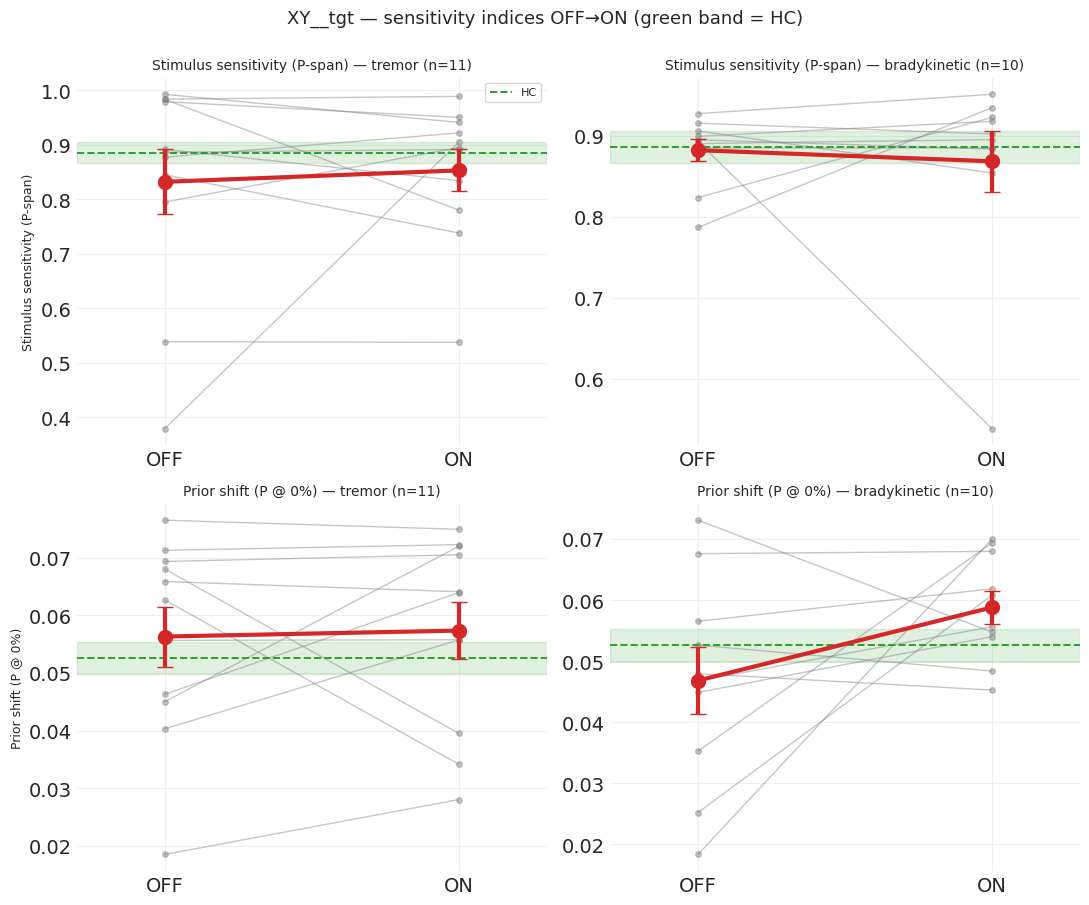

In [98]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9), squeeze=False)
for mi, metric in enumerate(metrics_idx):
    hc = idx_df[idx_df["subtype"] == "HC"][metric]; hc_m, hc_s = hc.mean(), hc.sem()
    for ax, sub in zip(axes[mi], ["tremor", "bradykinetic"]):
        pv = (pd_idx.pivot_table(index="subject_id", columns="medication", values=metric, observed=True)
              .dropna(subset=["off", "on"]))
        ss = pd_idx[pd_idx["subtype"] == sub]["subject_id"].unique()
        d = pv.loc[pv.index.isin(ss)]
        for _, r in d.iterrows():
            ax.plot([0, 1], [r["off"], r["on"]], "-o", color="gray", alpha=0.45, lw=1, ms=4)
        ax.errorbar([0, 1], [d["off"].mean(), d["on"].mean()], yerr=[d["off"].sem(), d["on"].sem()],
                    color="tab:red", lw=3, marker="o", ms=10, capsize=6, zorder=5)
        ax.axhspan(hc_m - hc_s, hc_m + hc_s, color="tab:green", alpha=0.15)
        ax.axhline(hc_m, color="tab:green", ls="--", lw=1.4, label="HC")
        ax.set_xticks([0, 1]); ax.set_xticklabels(["OFF", "ON"]); ax.set_xlim(-0.3, 1.3)
        ax.set_title(f"{ilabels[metric]} — {sub} (n={len(d)})", fontsize=10)
    axes[mi, 0].set_ylabel(ilabels[metric], fontsize=9)
axes[0, 0].legend(fontsize=8)
fig.suptitle(f"{CONFIG} — sensitivity indices OFF→ON (green band = HC)", fontsize=13, y=1.001)
plt.tight_layout(); plt.show()

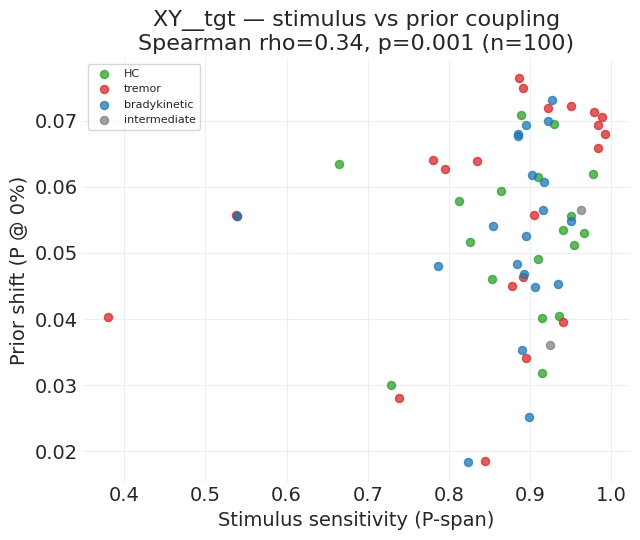

In [99]:
cmap = {"HC": "tab:green", "tremor": "tab:red", "bradykinetic": "tab:blue", "intermediate": "gray"}
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for sub, dd in idx_df.groupby("subtype", observed=True):
    ax.scatter(dd["stim_idx"], dd["prior_idx"], s=34, alpha=0.75, color=cmap.get(sub, "gray"), label=sub)
rho, p = spearmanr(idx_df["stim_idx"], idx_df["prior_idx"])
ax.set(xlabel=ilabels["stim_idx"], ylabel=ilabels["prior_idx"],
       title=f"{CONFIG} — stimulus vs prior coupling\nSpearman rho={rho:.2f}, p={p:.3f} (n={len(idx_df)})")
ax.spines[["top", "right"]].set_visible(False); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()